In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [2]:
image_path = "../output_videos/cropped_image.jpg"
image = cv.imread(image_path)
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

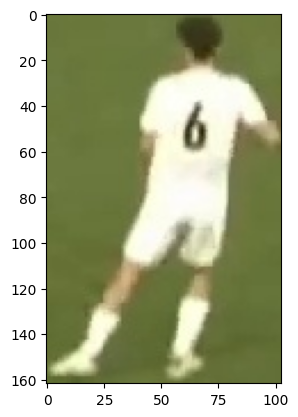

In [3]:
plt.imshow(image_rgb)
plt.show()

# Take the top half of the image

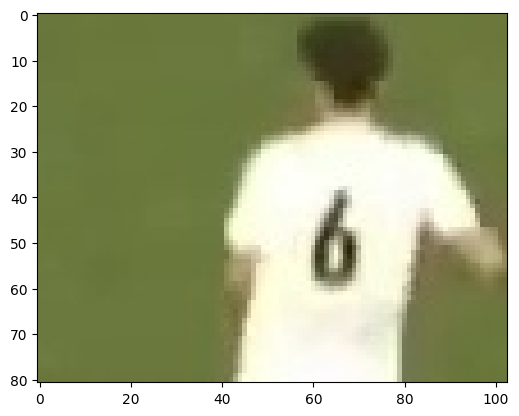

In [4]:
top_half = image_rgb[:image_rgb.shape[0] // 2, :, :]
plt.imshow(top_half)
plt.show()

# Cluster the image into two clusters

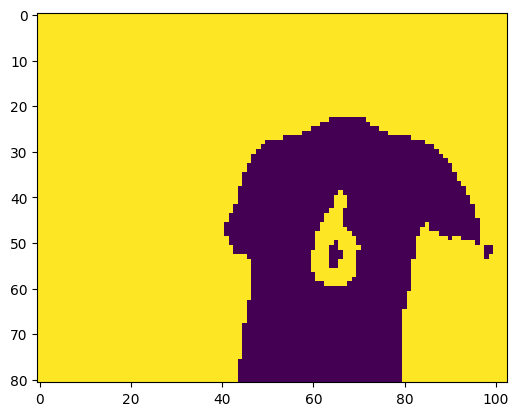

In [5]:
# Cluster the image into two clusters
image_2d = top_half.reshape((-1, 3))

# Perform KMeans clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0).fit(image_2d)

# Get the cluster labels
labels = kmeans.labels_

# Reshape labels back to the original image shape
clustered_image = labels.reshape(top_half.shape[0], top_half.shape[1])

# Display the clustered image
plt.imshow(clustered_image)
plt.show()

In [6]:
corner_cluster = [clustered_image[0, 0], clustered_image[0, -1],
                  clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_cluster), key=corner_cluster.count)
print("Non-player cluster label:", non_player_cluster)

Non-player cluster label: 1


In [7]:
player_cluster = 1 - non_player_cluster
print("Player cluster label:", player_cluster)

Player cluster label: 0


In [8]:
kmeans.cluster_centers_[player_cluster]

array([244.73238771, 243.97588652, 223.25295508])